In [68]:
import numpy as np

focus_timer = np.random.randint(0, 90)
print(f"Focus time: {focus_timer} minutes")

Focus time: 30 minutes


# Direct Marketing

## About: Data Set
>  Citation Request:
>   This dataset is public available for research. The details are described in [Moro et al., 2011]. 
>   Please include this citation if you plan to use this database:
> 
>   [Moro et al., 2011] S. Moro, R. Laureano and P. Cortez. Using Data Mining for Bank Direct Marketing: An Application of the CRISP-DM Methodology. 
>   In P. Novais et al. (Eds.), Proceedings of the European Simulation and Modelling Conference - ESM'2011, pp. 117-121, Guimarães, Portugal, October, 2011. EUROSIS.
> 
>   Available at: [pdf] http://hdl.handle.net/1822/14838
>                 [bib] http://www3.dsi.uminho.PrettyTable/pcortez/bib/2011-esm-1.txt
> 
> 1. Title: Bank Marketing
> 2. Sources
>    Created by: Paulo Cortez (Univ. Minho) and Sérgio Moro (ISCTE-IUL) @ 2012
> 3. Past Usage:
>    The full dataset was described and analyzed in:
> 
>    S. Moro, R. Laureano and P. Cortez. Using Data Mining for Bank Direct Marketing: An Application of the CRISP-DM Methodology. 
>    In P. Novais et al. (Eds.), Proceedings of the European Simulation and Modelling Conference - ESM'2011, pp. 117-121, Guimarães, 
>    Portugal, October, 2011. EUROSIS.
> 4. Relevant Information:
>    The data is related with direct marketing campaigns of a Portuguese banking institution. 
>    The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required, 
>    in order to access if the product (bank term deposit) would be (or not) subscribed. 
>    There are two datasets: 
>       1) bank-full.csv with all examples, ordered by date (from May 2008 to November 2010).
>       2) bank.csv with 10% of the examples (4521), randomly selected from bank-full.csv.
>    The smallest dataset is provided to test more computationally demanding machine learning algorithms (e.g. SVM).
>    The classification goal is to predict if the client will subscribe a term deposit (variable y).
> 5. Number of Instances: 45211 for bank-full.csv (4521 for bank.csv)
> 6. Number of Attributes: 16 + output attribute.
> 7. Attribute information:
>    For more information, read [Moro et al., 2011].
>    Input variables:
> ### bank client data:
> feature | descriPrettyTableion  
> ---|---  
> age | numeric  
> job | type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student", "blue-collar","self-employed","retired","technician","services")  
> marital | marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)  
> education | education level (categorical: "unknown","secondary","primary","tertiary")  
> default | has credit in default? (binary: "yes","no")  
> balance | average yearly balance, in euros (numeric)  
> housing | has housing loan? (binary: "yes","no")  
> loan | has personal loan? (binary: "yes","no")  
> contact | contact communication type (categorical: "unknown","telephone","cellular")  
> day | last contact day of the month (numeric)  
> month | last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")  
> duration | last contact duration, in seconds (numeric)  
> campaign | number of contacts performed during this campaign and for this client (numeric, includes last contact)  
> pdays | number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)  
> previous | number of contacts performed before this campaign and for this client (numeric)  
> poutcome | outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")  
> y | has the client subscribed a term deposit? (binary: "yes","no")  
> 8. Missing Attribute Values: None
> 
> https://www.sciencedirect.com/science/article/pii/S016792361400061X
> 

## Goals:
> how to oPrettyTableimize the sales process / call
- Predict if customer will sign on to term deposit
    - binary classification
- Get feature importance
    - Correlations

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import prettytable as PrettyTable
from sklearn.model_selection import train_test_split

# EDA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer

# Preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import KBinsDiscretizer

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_selector

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score

# Evaluation
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Fine tuning
from sklearn.model_selection import GridSearchCV




In [70]:
!ls ./data/data.csv

./data/data.csv


In [71]:
# Get Data

with open('./data/data.csv', 'r') as f:
    df_raw = pd.read_csv(f, delimiter=';')
    
df_raw.shape

(45211, 17)

In [72]:
df_raw.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [73]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [74]:
df_raw.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


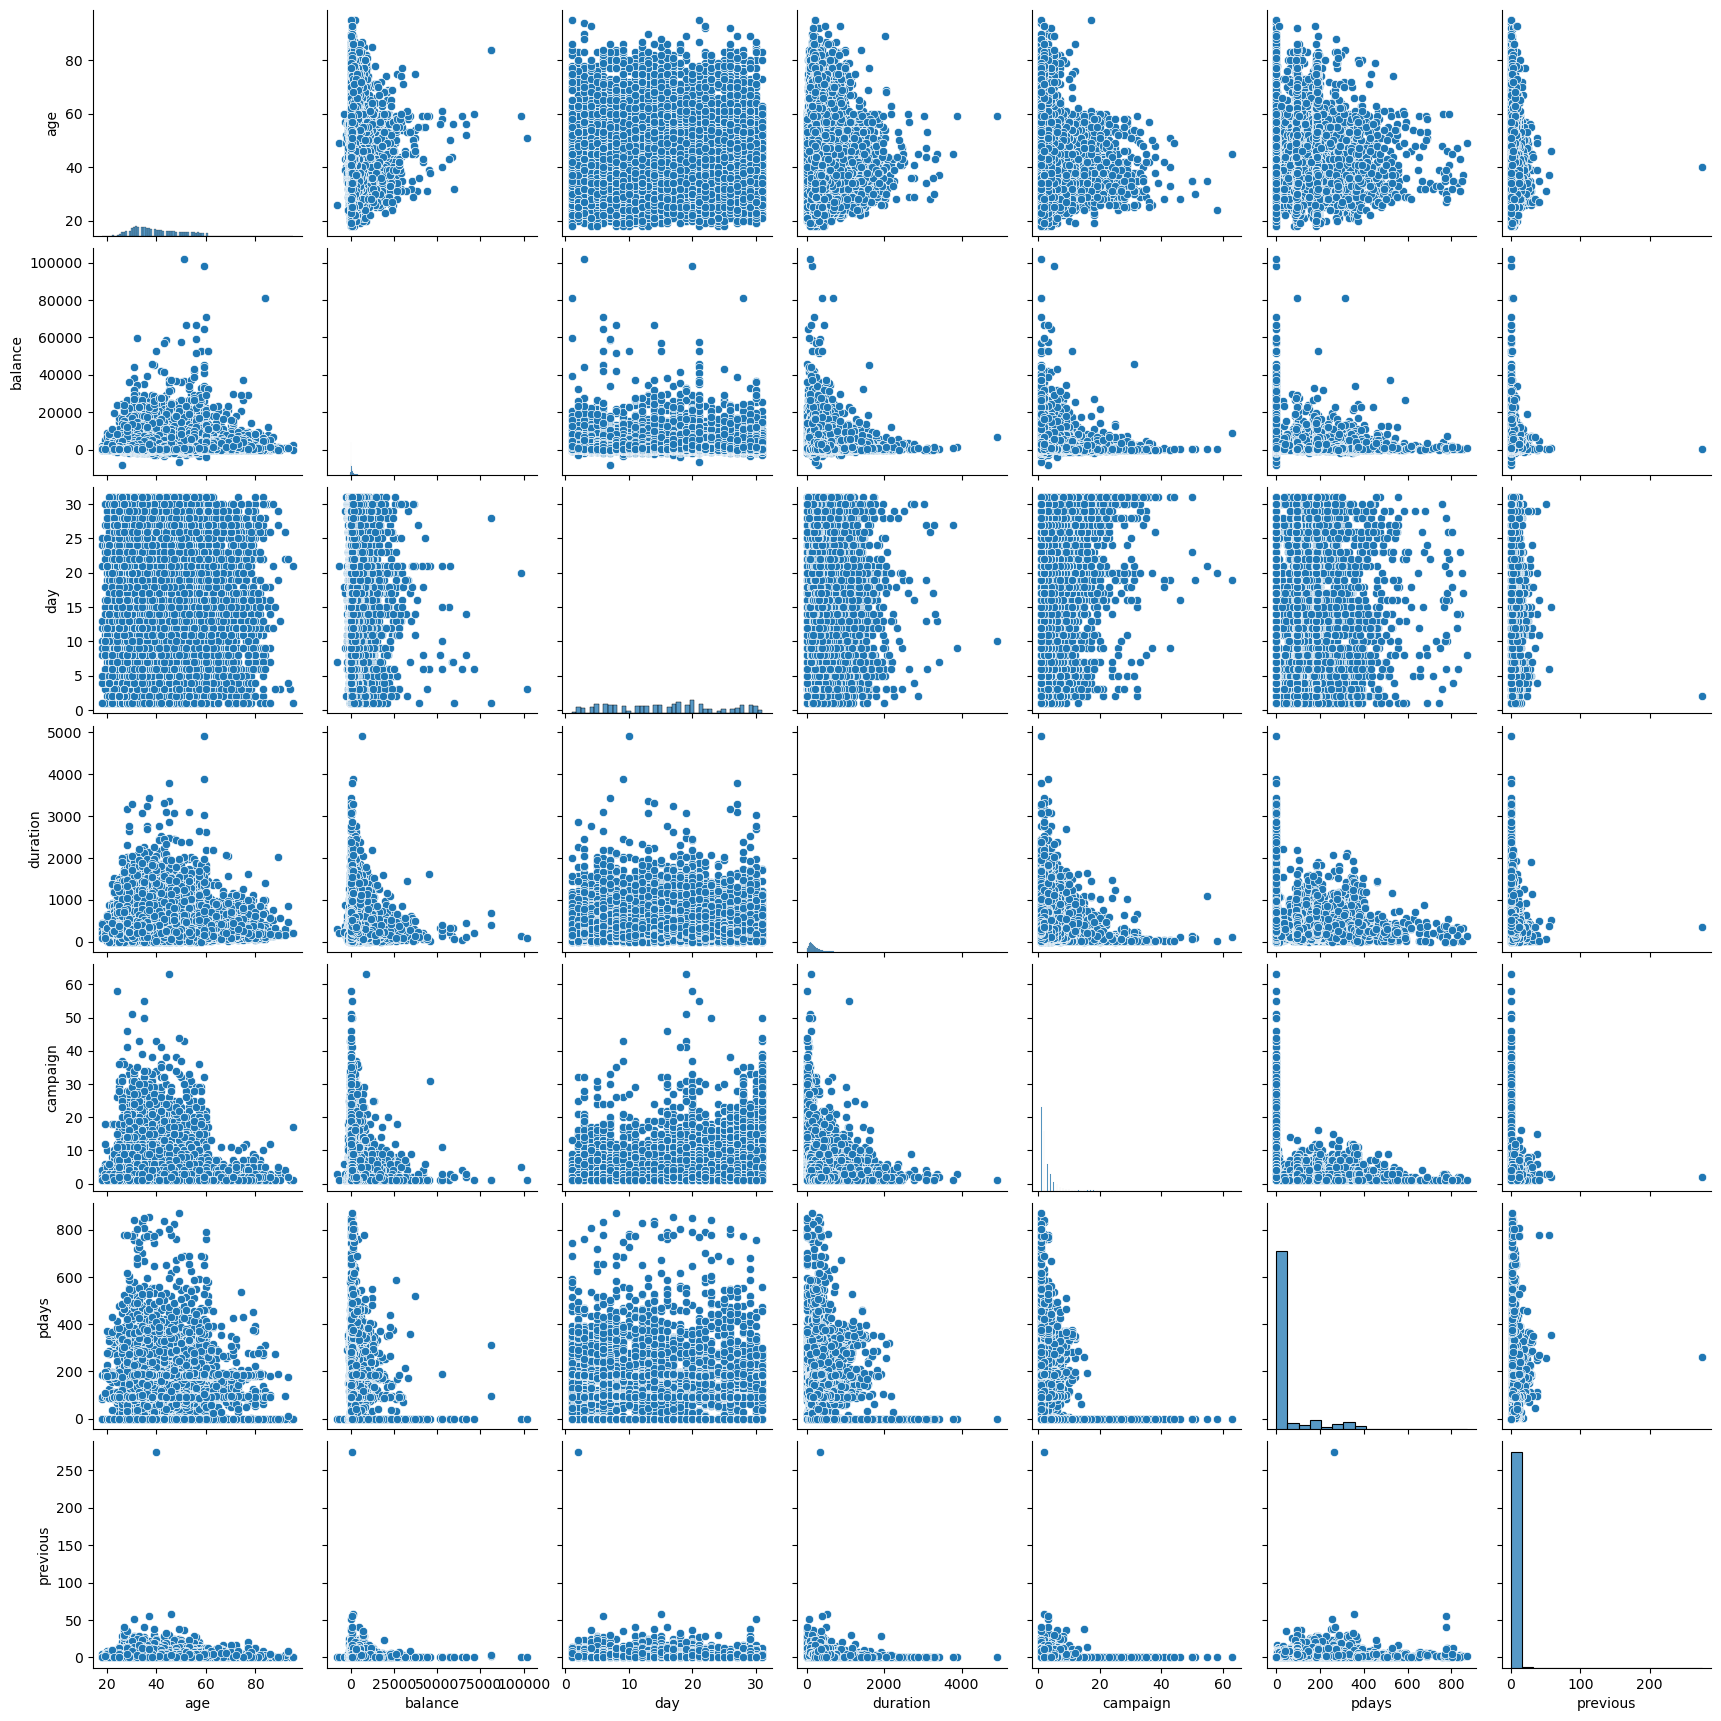

In [75]:
# scatter plots
sns.pairplot(df_raw.select_dtypes(include=['number']));

In [76]:

# Train/Test split
df_train, df_test = train_test_split(df_raw, train_size=0.3, random_state=7)

df_EDA = df_train.copy()
X_train = df_train.copy().drop('y', axis=1)
y_train = df_train['y']
X_train_num = X_train.select_dtypes(include=['number'])

X_test = df_test.copy().drop('y', axis=1)
y_test = df_test['y']

## EDA

In [77]:
# categorical counts

def get_counts(lst_columns):
    '''print counts of categorical var in a pretty table. prints % to see class imbalance'''
    table = PrettyTable.PrettyTable()
    table.field_names = ["Column", "Category", "Count", "Percentage"]
    for col in lst_columns:
        col_total = df_EDA[col].count()
        value_counts = df_EDA[col].value_counts()
        for cat, cnt in value_counts.items():
            pct = round(cnt / col_total * 100 ,2)
            table.add_row([col, cat, cnt, pct])
    print(table)

lst_columns = df_EDA.select_dtypes(include=['object']).columns
get_counts(lst_columns)


+-----------+---------------+-------+------------+
|   Column  |    Category   | Count | Percentage |
+-----------+---------------+-------+------------+
|    job    |  blue-collar  |  2927 |   21.58    |
|    job    |   management  |  2811 |   20.73    |
|    job    |   technician  |  2319 |    17.1    |
|    job    |     admin.    |  1586 |   11.69    |
|    job    |    services   |  1238 |    9.13    |
|    job    |    retired    |  664  |    4.9     |
|    job    | self-employed |  454  |    3.35    |
|    job    |  entrepreneur |  440  |    3.24    |
|    job    |   unemployed  |  387  |    2.85    |
|    job    |   housemaid   |  372  |    2.74    |
|    job    |    student    |  277  |    2.04    |
|    job    |    unknown    |   88  |    0.65    |
|  marital  |    married    |  8176 |   60.28    |
|  marital  |     single    |  3862 |   28.47    |
|  marital  |    divorced   |  1525 |   11.24    |
| education |   secondary   |  7013 |   51.71    |
| education |    tertiary   |  

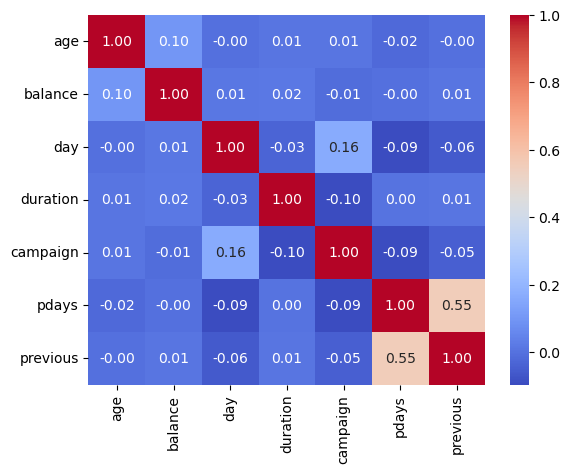

In [78]:
# correlation matrix
corr = df_EDA.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f');

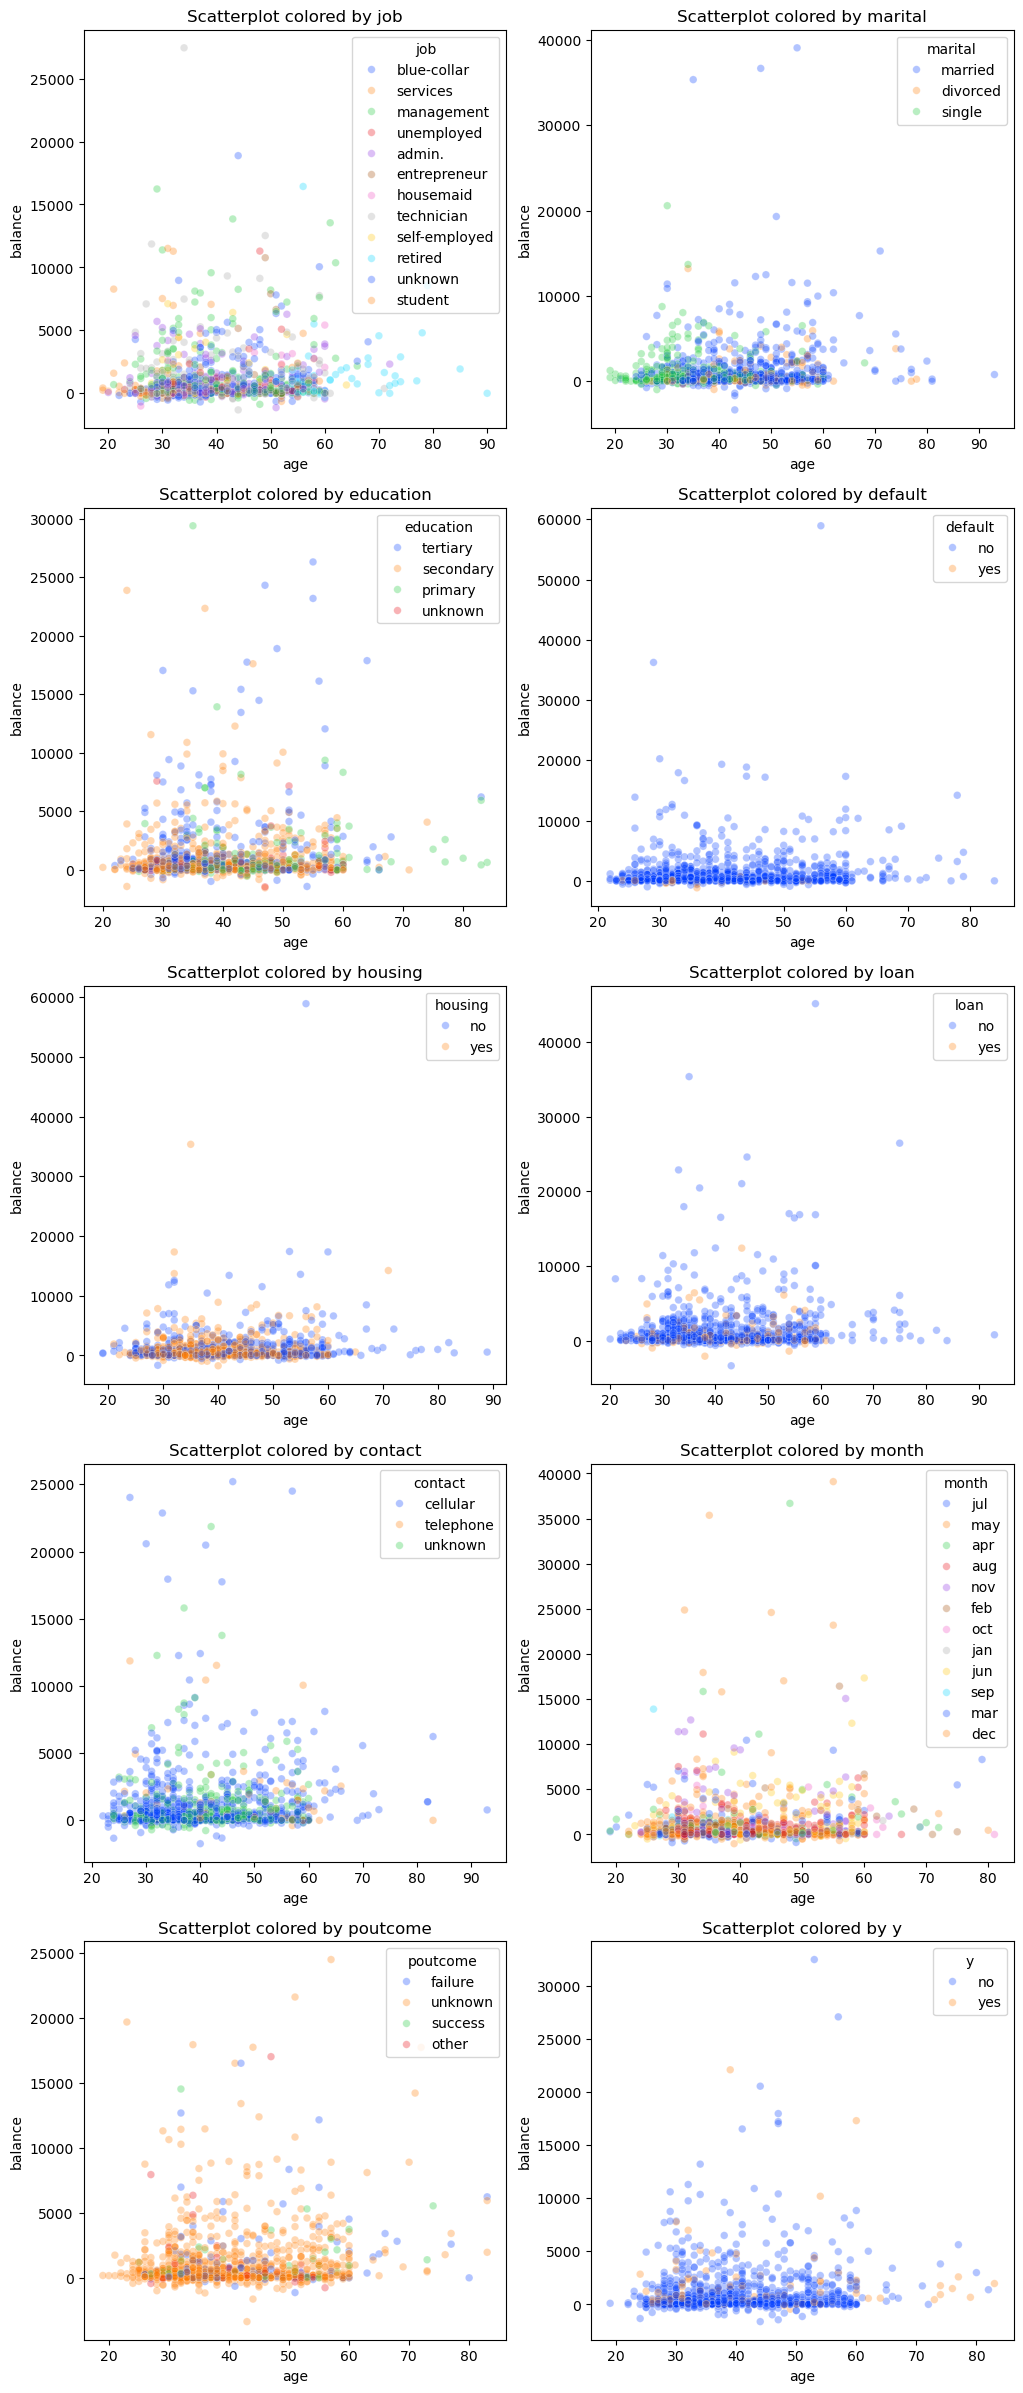

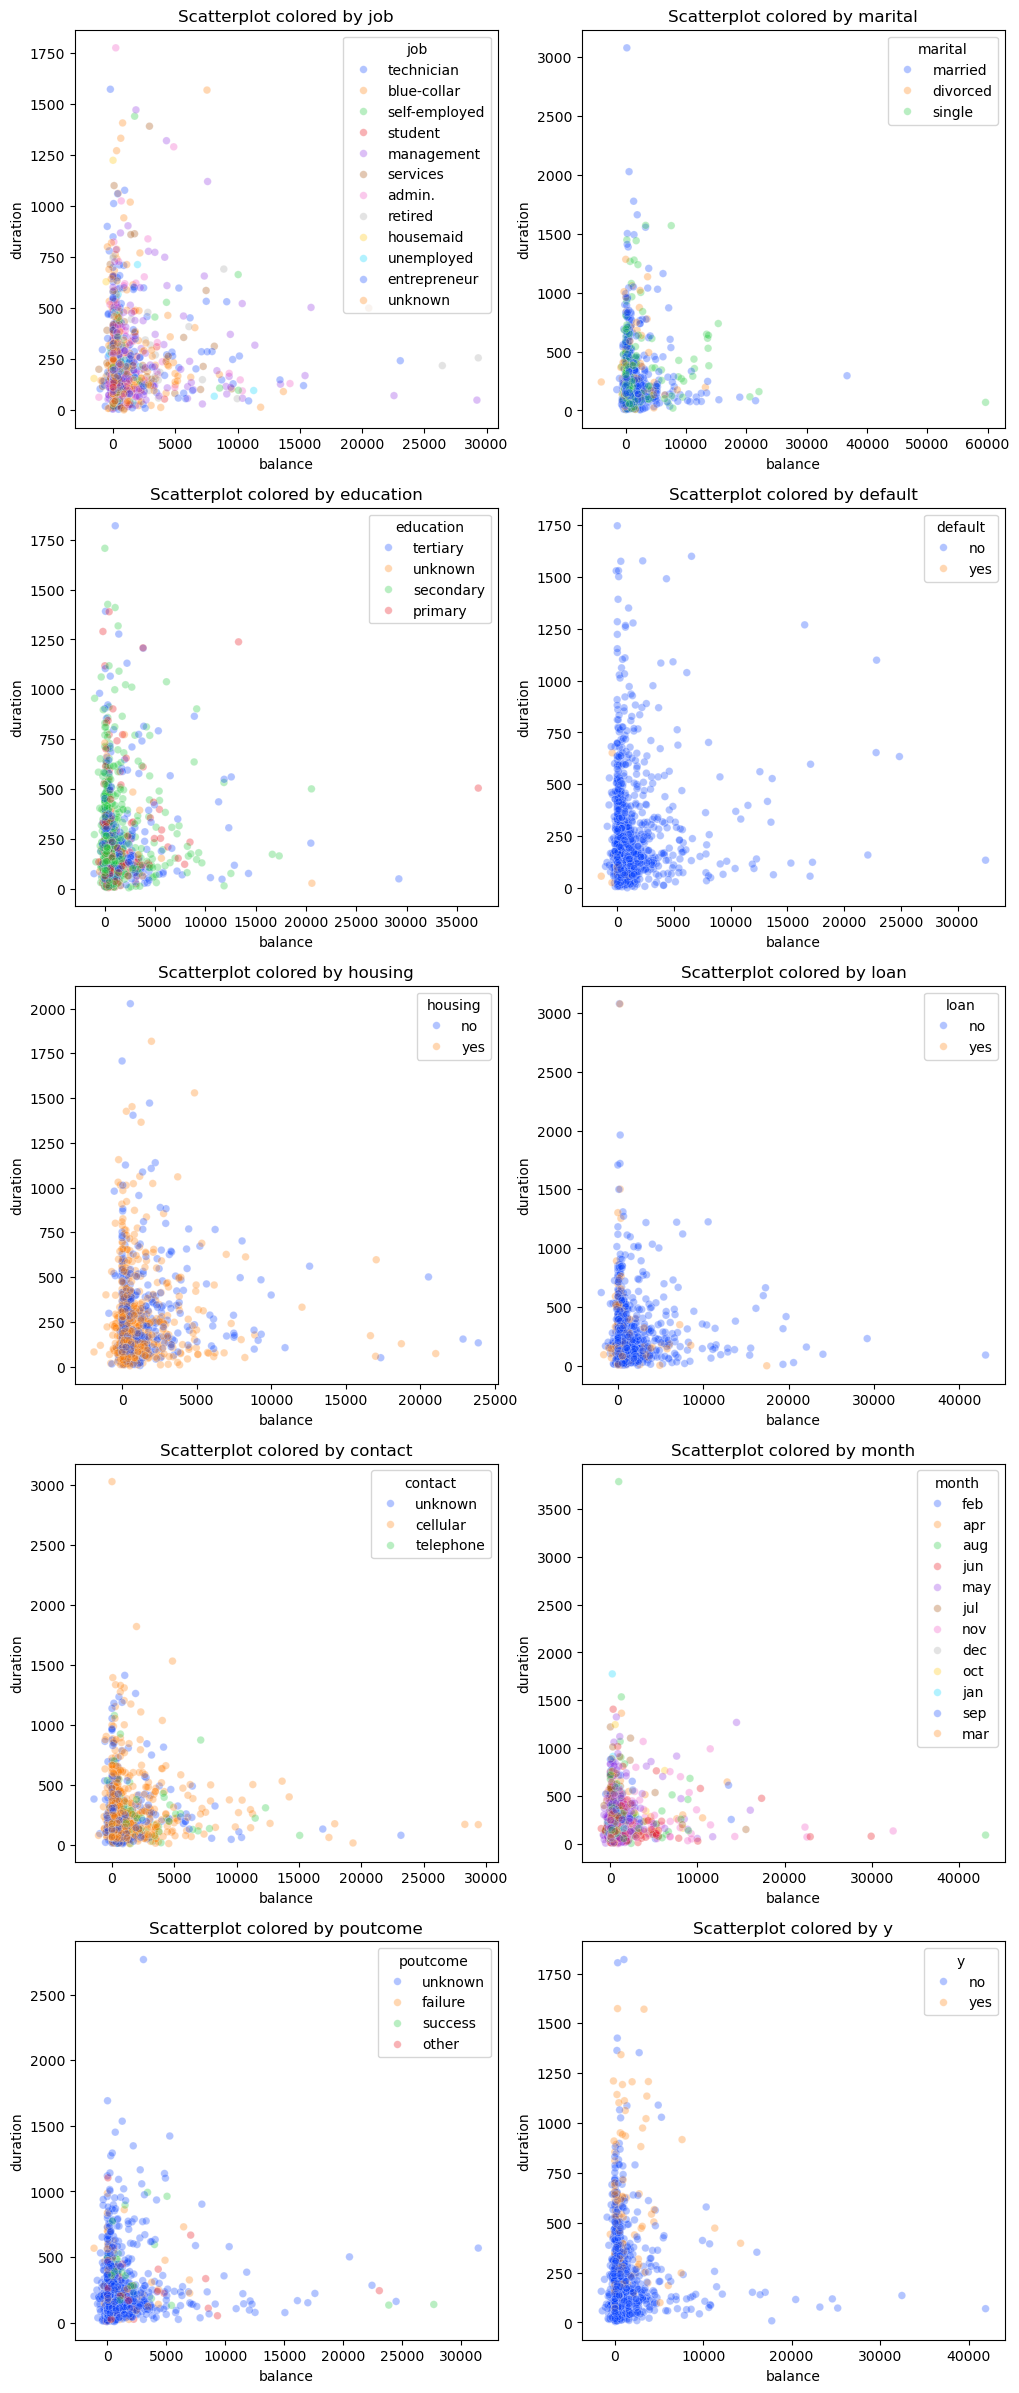

In [79]:
# Scatterplot with Highlighted Categories
class PlotCatFeatures():
    # feature1, feature2, cat_features, feature1_name=None, feature2_name=None, feature_name_2=None
    
    def from_series(self, x, y, color_by, title=None, ax=None, samples=None):
        '''
            Show categorical features as colors
            x        :   pd.Series
            y        :   pd.Series
            color_by :   pd.Series
            name     :   str
            ax       :   matplotlib axis
            samples  :   int, number of samples to plot
        '''
        assert isinstance(x, pd.Series), 'x is not series'
        assert isinstance(y, pd.Series), 'y is not a series'
        assert isinstance(color_by, pd.Series), 'color_by is not a series'
    
        if samples is not None:
            #TODO replace Iloc 
            index = np.random.choice(len(x), samples, replace=False)
            x = x.iloc[index]
            y = y.iloc[index]
            color_by = color_by.iloc[index]
            
        # generate new axes if not existant
        if not ax:
            fig, ax = plt.subplots()
            
        sns.scatterplot(x=x, y=y, hue=color_by, ax=ax, palette='bright', alpha=0.3, s=30)
        title and ax.set_title(title)
        
    def from_df(self, x, y, df_cat, samples=None):
        '''
            x: pd.Series
            y: pd.Series
        '''
        # creating figure
        columns = df_cat.columns
        figure_rows = len(columns) // 2 + len(columns) % 2
        fig, ax = plt.subplots(figure_rows, 2, figsize=(12, 6 * figure_rows))
        
        # looping over categorical features
        for i, col in enumerate(df_cat.columns):
            i_row, i_col = divmod(i, 2)
            self.from_series(x, y, df_cat[col], title=f"Scatterplot colored by {col}", ax=ax[i_row, i_col], samples=samples)
        
        
graph = PlotCatFeatures()
graph.from_df(df_EDA['age'], df_EDA['balance'], df_EDA.select_dtypes('object'), samples=1000)
graph.from_df(df_EDA['balance'], df_EDA['duration'], df_EDA.select_dtypes('object'), samples=1000)

### Findings:
- most observations in may 30%
- old people are retired and students are young
- young people more likely single
- younger people seem better educated
- housing loan suprisingly uniformly distributed -> bias in data?

### Categorical
Issue: Class Imbalances
- [ ] y -> oversampling
- [ ] ['poutcome', 'month__may', 'default', 'marital']
Issue: Sparce data
- [ ] previous

#### Preprocessing
Ordinal Encode: 
- [ ] default
- [ ] housing
- [ ] loan
- [ ] y
- [ ] campaign (ordinal data)

1hot Encode:
- [ ] job
- [ ] marital
- [ ] education
- [ ] contact

### Numerical
Issue: Skewed Data
- [ ] ['duration', 'balance'] -> log transform
- [ ] age -> downgrade (bin)


In [80]:
ohe = OneHotEncoder()
enc = OrdinalEncoder()
scl = StandardScaler()
bin = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform', subsample=None) # bining with transformer as this can be trained for new data / test set

def log1p_transform(data):
    '''
    Better than standard log transformation => handles zero values.
    ---
    params:
        data: pd.Series
    return: 
        log_data: pd.Series
    '''
    # scaling data to be poitive
    min = np.min(data)
    min_pos = abs(min)
    data = data + min_pos
    return np.log1p(data)
# Custom transformer functions
l1p = FunctionTransformer(func=log1p_transform, feature_names_out='one-to-one', validate=False)
    
# Pipelines
ppl_num = Pipeline([
    ('scaler', scl)
])
ppl_l1p = Pipeline([
    ('log1p', l1p),
    ('scaler', scl)
])
ppl_1ht = Pipeline([
    ('encoder', ohe),
])
ppl_ord = Pipeline([
    ('encoder', enc),
])
ppl_bin = Pipeline([
    ('bucktize', bin),
    ('encoder', enc),
])

In [81]:
# Column selectors

preprocessing = ColumnTransformer(
    transformers=[
        ('l1p', ppl_l1p, ['balance', 'duration']),
        ('1ht', ppl_1ht, ['job', 'marital', 'education', 'contact', 'poutcome', 'month']),
        ('ord', ppl_ord, ['default', 'housing', 'loan', 'previous']),
        ('bin', ppl_bin, ['age']),
        ('num', ppl_num, ['pdays'])
    ],
    remainder='passthrough'
)
preprocessing_num = ColumnTransformer(
    transformers=[
        ('l1p', ppl_l1p, ['balance', 'duration']),
        ('num', ppl_num, ['pdays', 'age']) #! age could give issues
    ],
    remainder='drop'
)

# Remainder columns after applying cat  + num:
# day: no years to transform to weekdays. | cyclical trend | ordinal
# campaign: number of contacts performed during this campaign for this client. | ordinal
preprocessing_pca = make_pipeline(
    preprocessing_num,
    PCA(n_components=2, random_state=7),
)


In [82]:
# PCA
ppl_pca = preprocessing_pca.fit(X_train)
pca_model = preprocessing_pca.named_steps['pca']
X_pca = pd.DataFrame(ppl_pca.transform(X_train))


pc1 = pca_model.components_[0]
pc2 = pca_model.components_[1]
explained_variance_ratio = pca_model.explained_variance_ratio_

print("Principal Component 1:", pc1)
print("Principal Component 2:", pc2)
print("Explained Variance Ratio:", explained_variance_ratio)

# pc1 explains 0.28% and pc2 0.25% of the variance of the data | 
# caveat being that there are only 4 numerical features resulting in a low utility

Principal Component 1: [-0.69481644 -0.23267217  0.06697163 -0.67720645]
Principal Component 2: [ 0.07288568  0.58180161  0.78574672 -0.19696869]
Explained Variance Ratio: [0.27971954 0.25247419]


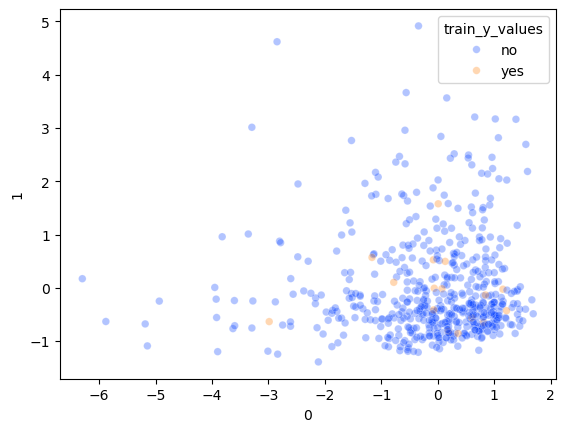

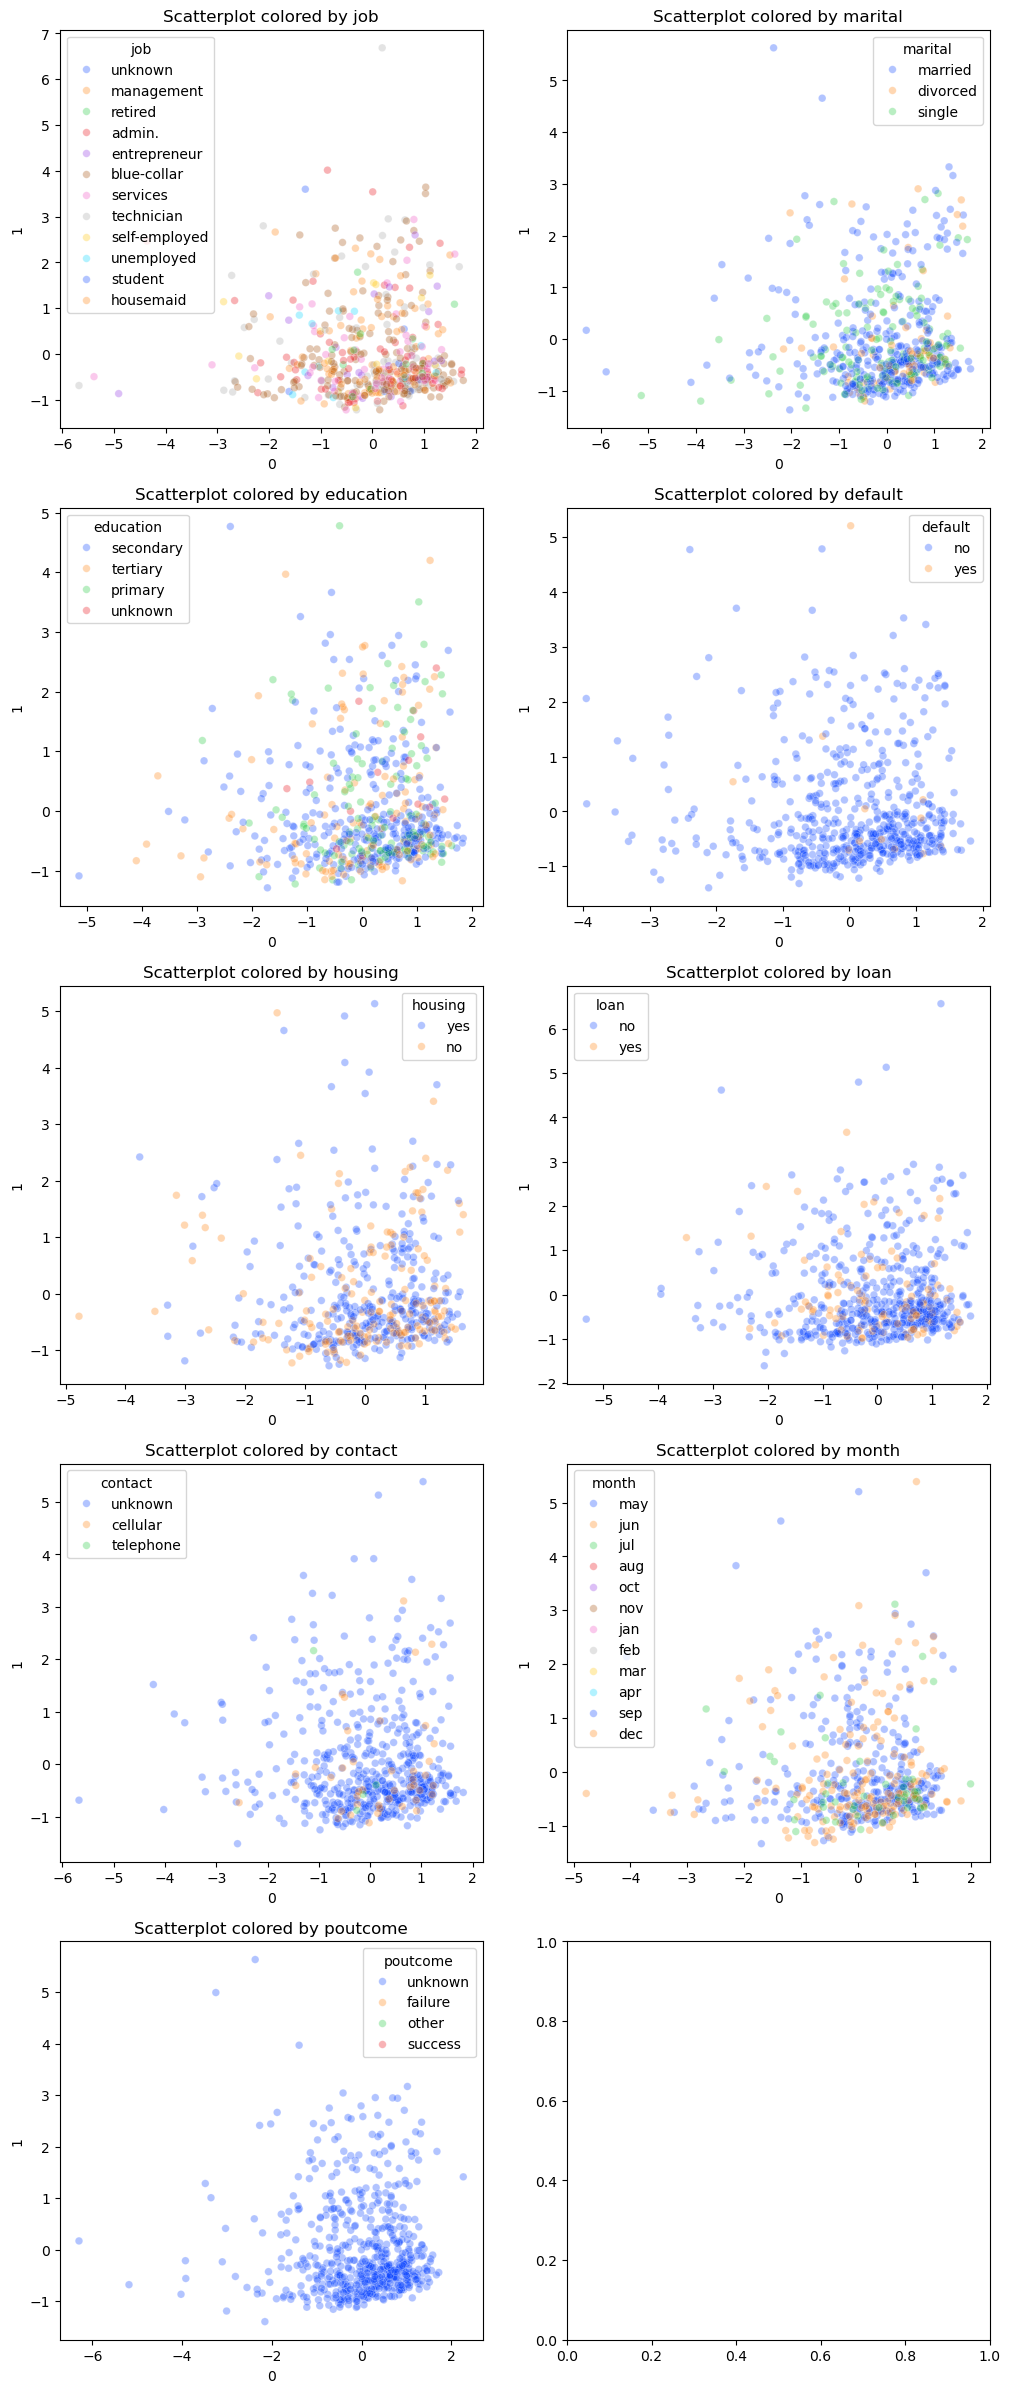

In [88]:
# Plot PCA
graph = PlotCatFeatures()
graph.from_series(X_pca.iloc[:,0], X_pca.iloc[:,1], pd.Series(y_train, name='train_y_values'), samples=5000)
graph.from_df(X_pca.iloc[:,0], X_pca.iloc[:,1], X_train.select_dtypes('object'), samples=5000)


In [84]:
# oversampling
# smote = make_pipeline(preprocessing, SMOTE(random_state=7))
# smote.fit(X_train, y_train)
# smote(X_train, y_train)

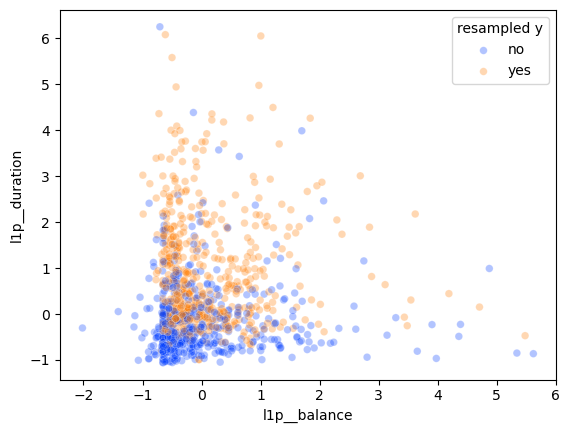

In [91]:
smote = imbalanced_make_pipeline(
    preprocessing,
    SMOTE(random_state=7)
)

x_resampled, y_resampled = smote.fit_resample(X_train, y_train)

x_resampled = pd.DataFrame(x_resampled, columns=smote.get_feature_names_out())

x_resampled['l1p__balance']
# plot the results

graph = PlotCatFeatures()
graph.from_series(x_resampled['l1p__balance'], x_resampled['l1p__duration'], pd.Series(y_resampled, name='resampled y'), samples=1000)




### Model Selection

In [ ]:
# Logistic Regression
pipeline_lr = make_pipeline(
    preprocessing,
    LogisticRegression(max_iter=1000, random_state=7)
)
pipeline_lr.fit(X_train, y_train)
pred_lr = pipeline_lr.predict(X_train)

print(classification_report(y_train, pred_lr))
print(confusion_matrix(y_train, pred_lr))


              precision    recall  f1-score   support

          no       0.92      0.98      0.95     11992
         yes       0.67      0.37      0.47      1571

    accuracy                           0.91     13563
   macro avg       0.79      0.67      0.71     13563
weighted avg       0.89      0.91      0.89     13563

[[11705   287]
 [  997   574]]


In [ ]:
# Logistic Regression with Oversampling
pipeline_balanced_lr = imbalanced_make_pipeline(
    preprocessing,
    SMOTE(random_state=7),
    LogisticRegression(max_iter=1000, random_state=7)
)
pipeline_balanced_lr.fit(X_train, y_train)

pred_balanced_lr = pipeline_balanced_lr.predict(X_train)
print(classification_report(y_train, pred_balanced_lr))
print(confusion_matrix(y_train, pred_balanced_lr))

              precision    recall  f1-score   support

          no       0.97      0.85      0.91     11992
         yes       0.42      0.81      0.55      1571

    accuracy                           0.85     13563
   macro avg       0.70      0.83      0.73     13563
weighted avg       0.91      0.85      0.87     13563

[[10227  1765]
 [  300  1271]]


In [ ]:
# Overfitting
# Random Forest
pipeline_rf = make_pipeline(
    preprocessing,
    RandomForestClassifier()
)
pipeline_rf.fit(X_train, y_train)
pred_rf = pipeline_rf.predict(X_train)
print(classification_report(y_train, pred_rf))
print(confusion_matrix(y_train, pred_rf))


              precision    recall  f1-score   support

          no       1.00      1.00      1.00     11992
         yes       1.00      1.00      1.00      1571

    accuracy                           1.00     13563
   macro avg       1.00      1.00      1.00     13563
weighted avg       1.00      1.00      1.00     13563

[[11992     0]
 [    1  1570]]


In [ ]:

# KNN
pipeline_knn = make_pipeline(
    preprocessing,
    KNeighborsClassifier(n_neighbors=5)
)
pipeline_knn.fit(X_train, y_train)
pred_knn = pipeline_knn.predict(X_train)
print(classification_report(y_train, pred_knn))
print(confusion_matrix(y_train, pred_knn))


              precision    recall  f1-score   support

          no       0.93      0.99      0.96     11992
         yes       0.78      0.41      0.54      1571

    accuracy                           0.92     13563
   macro avg       0.86      0.70      0.75     13563
weighted avg       0.91      0.92      0.91     13563

[[11813   179]
 [  920   651]]


In [ ]:

# MLP
pipeline_mlp = make_pipeline(
    preprocessing,
    MLPClassifier(learning_rate_init=0.02, random_state=7))

pipeline_mlp.fit(X_train, y_train)
pred_mlp = pipeline_mlp.predict(X_train)
print(classification_report(y_train, pred_mlp))
print(confusion_matrix(y_train, pred_mlp))

              precision    recall  f1-score   support

          no       0.97      0.98      0.97     11992
         yes       0.82      0.77      0.80      1571

    accuracy                           0.95     13563
   macro avg       0.89      0.88      0.88     13563
weighted avg       0.95      0.95      0.95     13563

[[11722   270]
 [  355  1216]]


In [ ]:
# Model Training/ Evaluation
# 


In [ ]:
# Fine Tuning

